# 前向传播与反向传播
在深度学习中，前向传播与反向传播是支撑其运转的两大核心支柱。它们如同一个硬币的两面，共同构成了神经网络从学习到应用的完整闭环，透彻理解这两个过程，是打开深度学习大门的第一把钥匙。

本文将带你一步步拆解这两个看似复杂的概念，用清晰的逻辑和生动的比喻，让你不仅知其然，更知其所以然。

-----

## 什么是前向传播与反向传播？
在深入细节之前，让我们先建立一个宏观的认知。

想象一下，你正在教一个孩子识别猫和狗。你给他看一张图片（输入），他根据自己大脑中已有的知识（网络参数，即权重和偏置）进行判断，然后告诉你这是猫（输出）。这个看图片 -> 大脑处理 -> 给出答案的过程，就是前向传播。

但孩子的判断可能出错。你告诉他：不对，这是狗。这个正确答案与孩子答案之间的差异，就是误差。孩子需要根据这个误差，回头去反思：我大脑里的哪些知识（参数）导致了这次误判？我应该如何调整它们，下次才能认对？这个根据误差，从后往前调整知识的过程，就是反向传播。

在神经网络中：
- **前向传播**：数据从输入层，经过隐藏层，最终到达输出层，并产生预测结果的过程。这是一个推理过程。
- **反向传播**：根据前向传播产生的预测结果与真实值之间的误差，从输出层开始，反向逐层计算每个参数（权重和偏置）对总误差的"贡献"大小（即梯度），并据此更新参数。这是一个学习过程。

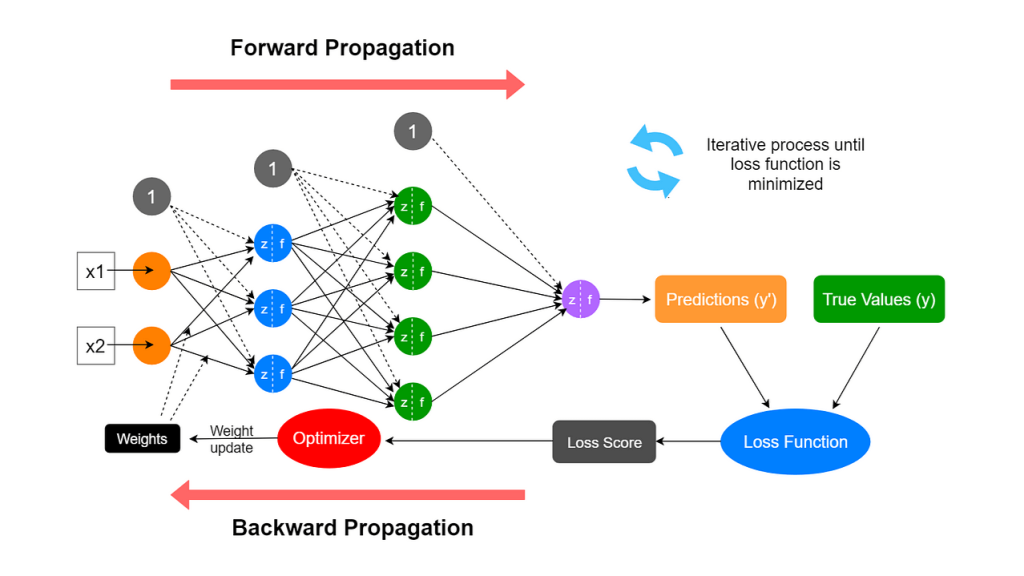

它们的关系就像是一个循环：前向传播产生输出和误差，反向传播根据误差调整参数，参数调整后又影响下一次前向传播的结果。这个循环不断进行，使得神经网络能够逐渐优化其性能，最终达到较好的预测效果。

![alt text](image.png)

----

## 前向传播：神经网络的推理过程
前向传播是神经网络进行预测的前向通道。让我们通过一个最简单的三层神经网络（输入层、一个隐藏层、输出层）来理解它。

### 核心概念与计算
假设我们要预测房价，输入是房屋面积 x。我们的微型网络结构如下：

- 输入层：一个神经元，接收 x。
- 隐藏层：一个神经元，拥有权重 w1 和偏置 b1。
- 输出层：一个神经元，拥有权重 w2 和偏置 b2，输出预测房价 y_pred。

前向传播的计算步骤如下：
1. **输入层到隐藏层**：输入 x 与权重 w1 和偏置 b1 的结合，然后通过一个激活函数(例如Sigmoid)得到隐藏层的输出 h。
$$z1 = w1 \cdot x + b1$$
$$a1 = \sigma(z1) = \frac{1}{1 + e^{-z1}}$$
- z1 是线性变换的结果
- a1 是经过激活函数处理后的结果

2. **隐藏层到输出层**：隐藏层的输出 a1 与权重 w2 和偏置 b2 的结合，得到最终的预测值 y_pred。
$$z2 = w2 \cdot a1 + b2$$
$$y\_pred = z2$$
- z2 是输出层的线性变换结果
- y_pred 是最终的预测结果

In [9]:
# 前向传播
import numpy as np

def sigmoid(x):
    """Sigmoid激活函数"""
    return 1 / (1 + np.exp(-x))

# 初始化网络参数（通常随机初始化，这里为演示指定值）
w1, b1 = 2.0, -1.0  # 隐藏层参数
w2, b2 = 1.5, 0.5   # 输出层参数

def forward_pass(x):
    """执行一次前向传播"""
    # 隐藏层计算
    z1 = w1 * x + b1
    a1 = sigmoid(z1)  # 应用激活函数
    
    # 输出层计算
    y_pred = w2 * a1 + b2  # 线性输出
    
    # 返回中间结果和最终预测，便于后续理解
    return {'z1': z1, 'a1': a1, 'y_pred': y_pred}

# 假设房屋面积为 3（单位：百平方米）
x_input = 3.0
result = forward_pass(x_input)
print(f"输入 x = {x_input}")
print(f"隐藏层线性输出 z1 = w1*x + b1 = {result['z1']:.4f}")
print(f"隐藏层激活输出 a1 = sigmoid(z1) = {result['a1']:.4f}")
print(f"最终预测房价 y_pred = w2*a1 + b2 = {result['y_pred']:.4f}")

输入 x = 3.0
隐藏层线性输出 z1 = w1*x + b1 = 5.0000
隐藏层激活输出 a1 = sigmoid(z1) = 0.9933
最终预测房价 y_pred = w2*a1 + b2 = 1.9900


这个 y_pred 就是网络对面积为3的房屋的预测价格。但显然，这个预测值（基于我们随便设定的参数）很可能与真实房价相差甚远。如何衡量这个差距并改进呢？这就需要损失函数和接下来的反向传播。

----

## 损失函数 : 好坏的衡量标尺
在反向传播开始之前，我们必须先量化预测值 y_pred 与真实值 y_true 之间的差距。这就是损失函数的作用。
常用的损失函数有：
- 均方误差（MSE）：$$L = \frac{1}{n} \sum_{i=1}^{n} (y\_pred - y\_true)^2$$
- 交叉熵损失：$$L = -\sum_{i=1}^{n} y\_true \log(y\_pred)$$

损失函数的值越小，说明预测结果越接近真实值。反之，损失值越大，说明预测结果与真实值的差距越大。

我们的目标就是通过反向传播来调整网络参数，使得损失函数的值尽可能小，从而提高模型的预测准确性。

----

## 反向传播：神经网络的学习引擎

反向传播是深度学习的学习算法核心。其本质是链式法则在神经网络中的高效应用。目标是计算损失函数 L 对每个参数（w1, b1, w2, b2）的偏导数（梯度），即 ∂L/∂w1, ∂L/∂b1 等。这些梯度指明了为了减小损失，每个参数应该朝哪个方向、以多大的幅度调整。

### 理解梯度：下山的方向与步幅
想象你蒙着眼站在一座山上（损失曲面），目标是找到山谷的最低点（最小损失）。你每走一步前，都需要用脚感受一下周围最陡的下坡方向。这个最陡的下坡方向就是梯度。反向传播就是帮你精确计算出脚下每一个点（对应每一组参数）的梯度。

### 反向传播计算步骤（链式求导）
我们继续沿用前面的微型网络，并假设真实房价 y_true = 2.5，损失函数为均方误差 L = (y_true - y_pred)^2。

反向传播从输出层开始，反向逐层计算梯度：
1. **输出层**：
   - 计算损失函数对输出层参数的梯度：
   $$\frac{\partial L}{\partial y\_pred} = 2(y\_pred - y\_true)$$
   $$\frac{\partial L}{\partial w2} = \frac{\partial L}{\partial y\_pred} \cdot \frac{\partial y\_pred}{\partial w2} = (∂L/∂y_pred) * a1 $$
   $$\frac{\partial L}{\partial b2} = \frac{\partial L}{\partial y\_pred} \cdot \frac{\partial y\_pred}{\partial b2} = (∂L/∂y_pred) * 1$$

2. **隐藏层**：
   - 计算损失函数对隐藏层参数的梯度：
   $$\frac{\partial L}{\partial a1} = \frac{\partial L}{\partial y\_pred} \cdot \frac{\partial y\_pred}{\partial a1}$$
   $$\frac{\partial L}{\partial z1} = \frac{\partial L}{\partial a1} \cdot \frac{\partial a1}{\partial z1} = (∂L/∂a1) * σ'(z1)$$
   $$\frac{\partial L}{\partial w1} = \frac{\partial L}{\partial z1} \cdot \frac{\partial z1}{\partial w1} = (∂L/∂z1) * x$$
   $$\frac{\partial L}{\partial b1} = \frac{\partial L}{\partial z1} \cdot \frac{\partial z1}{\partial b1} = (∂L/∂z1) * 1$$

In [10]:
# 接续前向传播的代码和结果
y_true = 2.5
y_pred = result['y_pred']
a1 = result['a1']
z1 = result['z1']
x = x_input

print(f"真实值 y_true = {y_true}")
print(f"预测值 y_pred = {y_pred:.4f}")
print(f"初始损失 Loss = {(y_true - y_pred)**2:.4f}")
print("\n--- 开始反向传播计算梯度 ---")

# 1. 计算损失对y_pred的梯度
dL_dy_pred = -2 * (y_true - y_pred)
print(f"梯度 ∂L/∂y_pred = -2*(y_true - y_pred) = {dL_dy_pred:.4f}")

# 2. 计算输出层参数 w2, b2 的梯度
dL_dw2 = dL_dy_pred * a1
dL_db2 = dL_dy_pred * 1
print(f"梯度 ∂L/∂w2 = (∂L/∂y_pred) * a1 = {dL_dw2:.4f}")
print(f"梯度 ∂L/∂b2 = (∂L/∂y_pred) * 1 = {dL_db2:.4f}")

# 3. 计算损失对隐藏层输出a1的梯度
dL_da1 = dL_dy_pred * w2
print(f"梯度 ∂L/∂a1 = (∂L/∂y_pred) * w2 = {dL_da1:.4f}")

# 4. 计算Sigmoid函数的导数在z1处的值
def sigmoid_derivative(x):
    """Sigmoid函数的导数"""
    s = sigmoid(x)
    return s * (1 - s)

sigma_prime_z1 = sigmoid_derivative(z1)
print(f"Sigmoid导数 σ'(z1) = σ(z1)*(1-σ(z1)) = {sigma_prime_z1:.4f}")

# 5. 计算隐藏层参数 w1, b1 的梯度
dL_dw1 = dL_da1 * sigma_prime_z1 * x
dL_db1 = dL_da1 * sigma_prime_z1 * 1
print(f"梯度 ∂L/∂w1 = (∂L/∂a1) * σ'(z1) * x = {dL_dw1:.4f}")
print(f"梯度 ∂L/∂b1 = (∂L/∂a1) * σ'(z1) * 1 = {dL_db1:.4f}")

真实值 y_true = 2.5
预测值 y_pred = 1.9900
初始损失 Loss = 0.2601

--- 开始反向传播计算梯度 ---
梯度 ∂L/∂y_pred = -2*(y_true - y_pred) = -1.0201
梯度 ∂L/∂w2 = (∂L/∂y_pred) * a1 = -1.0133
梯度 ∂L/∂b2 = (∂L/∂y_pred) * 1 = -1.0201
梯度 ∂L/∂a1 = (∂L/∂y_pred) * w2 = -1.5301
Sigmoid导数 σ'(z1) = σ(z1)*(1-σ(z1)) = 0.0066
梯度 ∂L/∂w1 = (∂L/∂a1) * σ'(z1) * x = -0.0305
梯度 ∂L/∂b1 = (∂L/∂a1) * σ'(z1) * 1 = -0.0102


现在，我们得到了所有参数的梯度。这些负值意味着，如果增加这些参数的值，损失会增大（因为梯度方向是上升方向）。为了减小损失，我们应该沿着梯度的反方向调整参数。

-------

## 参数更新 : 梯度下降
拿到梯度后，我们需要更新参数以减小损失。最常用的更新方法是梯度下降：
$$\theta = \theta - \alpha \cdot \frac{\partial L}{\partial \theta}$$

其中，θ 代表任一参数（如 w1, b1 等），α 是学习率，控制每次更新的步幅大小。

通过不断迭代前向传播和反向传播，参数逐渐调整，损失函数的值不断降低，模型的预测能力逐渐提升。

参数 = 参数 - 学习率 * 梯度

In [11]:
learning_rate = 0.1

# 更新参数
w1_new = w1 - learning_rate * dL_dw1
b1_new = b1 - learning_rate * dL_db1
w2_new = w2 - learning_rate * dL_dw2
b2_new = b2 - learning_rate * dL_db2

print("--- 更新后的参数 ---")
print(f"w1: {w1:.4f} -> {w1_new:.4f}")
print(f"b1: {b1:.4f} -> {b1_new:.4f}")
print(f"w2: {w2:.4f} -> {w2_new:.4f}")
print(f"b2: {b2:.4f} -> {b2_new:.4f}")

# 用新参数做一次前向传播，验证损失是否减小
def forward_pass_with_params(x, w1, b1, w2, b2):
    z1 = w1 * x + b1
    a1 = sigmoid(z1)
    y_pred = w2 * a1 + b2
    return y_pred

y_pred_new = forward_pass_with_params(x_input, w1_new, b1_new, w2_new, b2_new)
loss_new = (y_true - y_pred_new)**2
print(f"\n用新参数预测: y_pred_new = {y_pred_new:.4f}")
print(f"更新后的损失 New Loss = {loss_new:.4f}")
print(f"损失变化: {loss_new - (y_true-y_pred)**2:.4f} (负值表示损失减小)")

--- 更新后的参数 ---
w1: 2.0000 -> 2.0031
b1: -1.0000 -> -0.9990
w2: 1.5000 -> 1.6013
b2: 0.5000 -> 0.6020

用新参数预测: y_pred_new = 2.1927
更新后的损失 New Loss = 0.0944
损失变化: -0.1657 (负值表示损失减小)
